# 02 — Math and PyTorch Prerequisites for RL

| Course Week | Notebook | Topics |
|---|---|---|
| Week 1 | 01_intro_rl.ipynb | What is RL, agent-environment loop, overview |
| **Week 1** | **02_math_and_pytorch.ipynb** | **Probability, gradients, autograd** |
| Week 1 | 03_gym_intro.ipynb | Gymnasium API, first environment |

This notebook is a **math-and-code warm-up**.  You will not write a single RL algorithm here —
instead you will build the mathematical and software foundation that every RL algorithm relies on.

## Learning Objectives

By the end of this notebook you will be able to:

1.  **Manipulate random variables** — compute expectations, conditional probabilities, and use the law of total
    probability.
2.  **Compute gradients by hand and with code** — understand the chain rule and the difference between gradient
    ascent and descent.
3.  **Derive the log-derivative trick** $\nabla_\theta \log \pi(a\mid s) = \frac{\nabla_\theta \pi(a\mid s)}{\pi(a\mid s)}$,
    the cornerstone of policy-gradient RL.
4.  **Use PyTorch autograd** — build computational graphs, call `.backward()`, and read `.grad`.
5.  **Train a linear regression and a simple neural net** with gradient descent in PyTorch.
6.  **Sample from categorical distributions** and understand why `log_softmax` is numerically stable.

In [1]:
# Setup: imports used throughout this notebook
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.distributions as dist

# Determine the project root (parent of notebooks/ directory)
# Works whether CWD is the project root or the notebooks/ folder
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("All imports loaded successfully.")
print(f"NumPy version : {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Figures will be saved to: {os.path.abspath(FIG_DIR)}")

All imports loaded successfully.
NumPy version : 2.4.6
PyTorch version: 2.13.0+cu130
Figures will be saved to: /workspace/data/vggt-omega/rl/outputs/figures


## Probability Review

### Random Variables

A **random variable** $X$ is a function that maps outcomes of a random process to real numbers.

- **Discrete**: $X \in \{x_1, x_2, \dots\}$  — e.g., the outcome of a die roll.
- **Continuous**: $X \in \mathbb{R}$ — e.g., the time until a bus arrives.

### Probability Mass / Density Function

- **Discrete**: $p(x) = P(X = x)$  (PMF).
- **Continuous**: $f(x)$ such that $P(a \le X \le b) = \int_a^b f(x)\,dx$  (PDF).

### Expectation

The **expected value** (mean) of a function $g$ of a random variable $X$ is:

$$
\mathbb{E}[g(X)] =
\begin{cases}
\displaystyle\sum_{x} g(x)\,p(x), & X \text{ discrete}, \\[8pt]
\displaystyle\int_{-\infty}^{\infty} g(x)\,f(x)\,dx, & X \text{ continuous}.
\end{cases}
$$

**Linearity of expectation** (always holds — no independence required):

$$
\mathbb{E}[aX + bY] = a\,\mathbb{E}[X] + b\,\mathbb{E}[Y].
$$

### Conditional Probability

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \qquad P(B) > 0.
$$

For a random variable $Y$ conditioned on $X = x$:

$$
p(y \mid x) = \frac{p(x, y)}{p(x)}.
$$

### Law of Total Probability

$$
p(y) = \sum_{x} p(y \mid x)\,p(x) \quad\text{(discrete)},
\qquad
p(y) = \int p(y \mid x)\,p(x)\,dx \quad\text{(continuous)}.
$$

### Law of Total Expectation

A closely related result:

$$
\mathbb{E}[X] = \mathbb{E}\big[\mathbb{E}[X \mid Y]\big] = \sum_y \mathbb{E}[X \mid Y = y]\,P(Y = y).
$$

### Why This Matters for RL

Understanding probability is essential because **everything in RL is a random variable**:

| RL Concept | Probabilistic Formulation |
|---|---|
| **Return** $G_t$ | $G_t = \sum_{k=0}^\infty \gamma^k R_{t+k+1}$ — a random variable |
| **State-value function** $V^\pi(s)$ | $V^\pi(s) = \mathbb{E}[G_t \mid S_t = s]$ — an **expectation** |
| **Action-value function** $Q^\pi(s,a)$ | $Q^\pi(s,a) = \mathbb{E}[G_t \mid S_t = s, A_t = a]$ — a **conditional expectation** |
| **Bellman equation** | $V^\pi(s) = \sum_a \pi(a\mid s)\sum_{s'} P(s'\mid s,a)[R + \gamma V^\pi(s')]$ — law of total probability |

If you are comfortable with expectation and conditional probability, the Bellman equation will feel natural.

E[X] = 3.500  (theoretical = 3.5)
E[X | Y=1] = 4.998  (theoretical = 5.0)
E[X | Y=0] = 1.996  (theoretical = 2.0)
P(Y=1) = 0.501  (theoretical = 0.5)
Law of total expectation check: 3.500  (should match E[X] = 3.500)


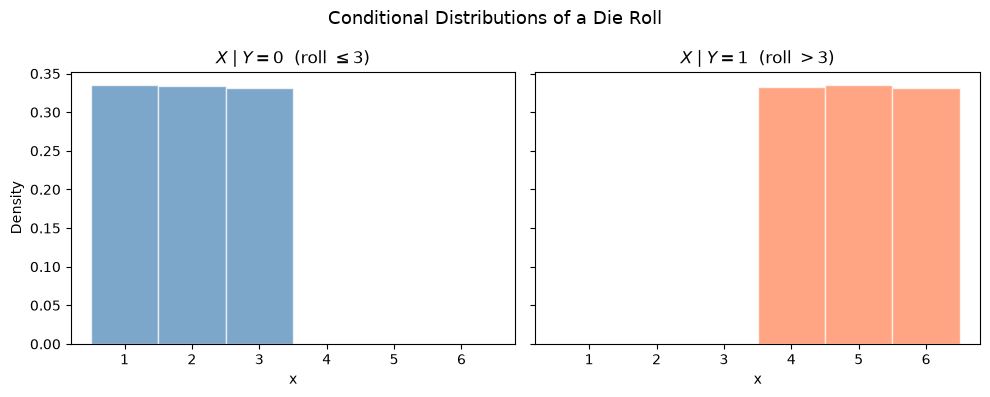

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# %matplotlib inline

# ----------------------------------------------------------------
# Simulate a joint distribution P(X, Y) where:
#   X = die roll (1..6),  Y = 1 if roll > 3, else 0
# ----------------------------------------------------------------
rng = np.random.default_rng(42)
N = 100_000
x = rng.integers(1, 7, size=N)        # uniform die
y = (x > 3).astype(int)                # Y = 1 if x > 3

# --- Empirical expectation E[X] ---
E_X = x.mean()
print(f"E[X] = {E_X:.3f}  (theoretical = 3.5)")

# --- Conditional expectation E[X | Y=1] ---
E_X_given_Y1 = x[y == 1].mean()
print(f"E[X | Y=1] = {E_X_given_Y1:.3f}  (theoretical = 5.0)")

# --- Conditional expectation E[X | Y=0] ---
E_X_given_Y0 = x[y == 0].mean()
print(f"E[X | Y=0] = {E_X_given_Y0:.3f}  (theoretical = 2.0)")

# --- Law of total probability: P(Y=1) ---
p_y1 = y.mean()
print(f"P(Y=1) = {p_y1:.3f}  (theoretical = 0.5)")

# --- Check law of total expectation: E[X] = E[X|Y=0]P(Y=0) + E[X|Y=1]P(Y=1) ---
p_y0 = 1 - p_y1
check = E_X_given_Y0 * p_y0 + E_X_given_Y1 * p_y1
print(f"Law of total expectation check: {check:.3f}  (should match E[X] = {E_X:.3f})")

# ----------------------------------------------------------------
# Visualise the conditional distributions
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(x[y == 0], bins=np.arange(0.5, 7.5), density=True,
             alpha=0.7, color="steelblue", edgecolor="white")
axes[0].set_title(r"$X \mid Y=0$  (roll $\leq 3$)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")

axes[1].hist(x[y == 1], bins=np.arange(0.5, 7.5), density=True,
             alpha=0.7, color="coral", edgecolor="white")
axes[1].set_title(r"$X \mid Y=1$  (roll $> 3$)")
axes[1].set_xlabel("x")

fig.suptitle("Conditional Distributions of a Die Roll", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb02_conditional_dist.png", dpi=150)
plt.show()

## Gradient and Partial Derivative

### Partial Derivative

For a function $f : \mathbb{R}^n \to \mathbb{R}$, the **partial derivative** w.r.t. $x_i$ is

$$
\frac{\partial f}{\partial x_i} = \lim_{h \to 0} \frac{f(x_1,\dots,x_i + h,\dots,x_n) - f(x_1,\dots,x_n)}{h}.
$$

### Gradient

The **gradient** is the vector of all partial derivatives:

$$
\nabla f(\mathbf{x}) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\[4pt]
\frac{\partial f}{\partial x_2} \\[4pt]
\vdots \\[4pt]
\frac{\partial f}{\partial x_n}
\end{bmatrix}.
$$

The gradient points in the *direction of steepest increase* of $f$.

### Chain Rule

If $z = f(y)$ and $y = g(x)$, then

$$
\frac{dz}{dx} = \frac{df}{dy}\,\frac{dg}{dx}.
$$

For vectors: if $\mathbf{y} = g(\mathbf{x})$ and $z = f(\mathbf{y})$, then

$$
\nabla_{\mathbf{x}} z = \left(\frac{\partial \mathbf{y}}{\partial \mathbf{x}}\right)^\top \nabla_{\mathbf{y}} z,
$$

where $\frac{\partial \mathbf{y}}{\partial \mathbf{x}}$ is the Jacobian matrix.

### Gradient Ascent vs. Descent

| Goal | Update Rule | Use Case |
|---|---|---|
| **Minimise** $f$ (descent) | $\mathbf{x}_{t+1} = \mathbf{x}_t - \alpha \nabla f(\mathbf{x}_t)$ | Loss minimisation, supervised learning |
| **Maximise** $f$ (ascent) | $\mathbf{x}_{t+1} = \mathbf{x}_t + \alpha \nabla f(\mathbf{x}_t)$ | Reward maximisation in RL (policy gradient) |

$\alpha > 0$ is the **learning rate** (step size).

### Why This Matters for RL

Policy-gradient methods *maximise* the expected return $J(\theta) = \mathbb{E}[G_t]$ by performing **gradient ascent** on the policy parameters $\theta$:

$$
\theta \leftarrow \theta + \alpha \nabla_\theta J(\theta).
$$

This is the opposite of supervised learning, where we minimise a loss!

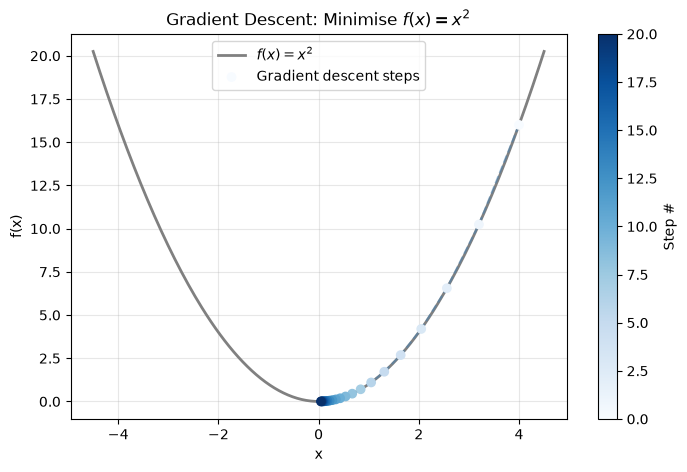

Final x = 0.046117  (optimum = 0)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# %matplotlib inline

# ----------------------------------------------------------------
# Gradient descent on f(x) = x^2
#   f'(x) = 2x
#   minimum at x = 0
# ----------------------------------------------------------------
def f(x):
    return x**2

def df(x):
    return 2 * x

alpha = 0.1               # learning rate
x = 4.0                   # start point
n_steps = 20
history = [x]

for step in range(n_steps):
    x = x - alpha * df(x)   # gradient DESCENT
    history.append(x)

xs = np.linspace(-4.5, 4.5, 200)
plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label=r"$f(x)=x^2$", color="gray", lw=2)
plt.scatter(history, f(np.array(history)),
            c=np.arange(len(history)), cmap="Blues", zorder=5,
            label="Gradient descent steps")
plt.plot(history, f(np.array(history)), "--", color="steelblue", alpha=0.5)
plt.colorbar(label="Step #")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Gradient Descent: Minimise $f(x)=x^2$")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/nb02_gd_min.png", dpi=150)
plt.show()

print(f"Final x = {history[-1]:.6f}  (optimum = 0)")

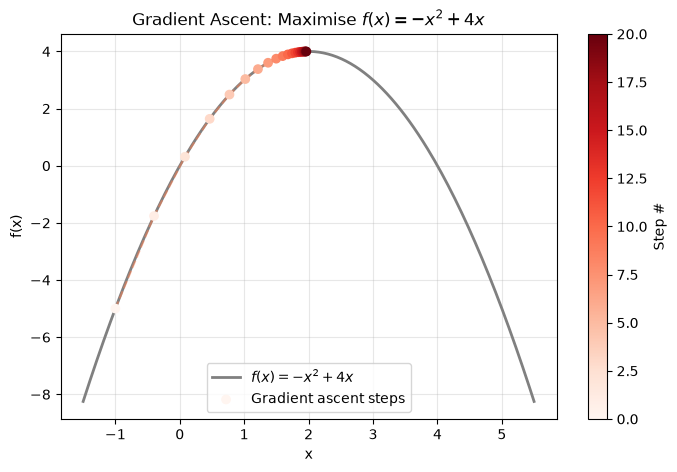

Final x = 1.965412  (optimum = 2)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# %matplotlib inline

# ----------------------------------------------------------------
# Gradient ascent on f(x) = -x^2 + 4x
#   f'(x) = -2x + 4
#   maximum at x = 2
# ----------------------------------------------------------------
def f(x):
    return -x**2 + 4 * x

def df(x):
    return -2 * x + 4

alpha = 0.1
x = -1.0
n_steps = 20
history = [x]

for step in range(n_steps):
    x = x + alpha * df(x)   # gradient ASCENT (note: +)
    history.append(x)

xs = np.linspace(-1.5, 5.5, 200)
plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), label=r"$f(x)=-x^2+4x$", color="gray", lw=2)
plt.scatter(history, f(np.array(history)),
            c=np.arange(len(history)), cmap="Reds", zorder=5,
            label="Gradient ascent steps")
plt.plot(history, f(np.array(history)), "--", color="coral", alpha=0.5)
plt.colorbar(label="Step #")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Gradient Ascent: Maximise $f(x)=-x^2+4x$")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/nb02_ga_max.png", dpi=150)
plt.show()

print(f"Final x = {history[-1]:.6f}  (optimum = 2)")

## The Log-Derivative Trick

This simple algebraic identity is the engine behind **REINFORCE** and every policy-gradient algorithm.

### Derivation

Let $\pi_\theta(a \mid s)$ be a policy parameterised by $\theta$ (e.g., a neural network).
We want the gradient of the expected return w.r.t. $\theta$.

The trick:

$$
\nabla_\theta \log \pi_\theta(a \mid s)
= \frac{\nabla_\theta \pi_\theta(a \mid s)}{\pi_\theta(a \mid s)}.
$$

**Step-by-step:**

1.  Recall the derivative of $\log$: $\displaystyle \frac{d}{dx} \log u = \frac{1}{u} \frac{du}{dx}$.
2.  Apply the chain rule with $u = \pi_\theta(a \mid s)$:

    $$
    \nabla_\theta \log \pi_\theta(a \mid s)
    = \frac{1}{\pi_\theta(a \mid s)} \, \nabla_\theta \pi_\theta(a \mid s).
    $$

3.  Rearranging:

    $$
    \nabla_\theta \pi_\theta(a \mid s) = \pi_\theta(a \mid s) \, \nabla_\theta \log \pi_\theta(a \mid s).
    $$

### Why is this useful?

The gradient of an expectation can be rewritten as an **expectation of a gradient**:

$$
\nabla_\theta \mathbb{E}_{a \sim \pi_\theta}[R]
= \mathbb{E}_{a \sim \pi_\theta}\big[ R \; \nabla_\theta \log \pi_\theta(a \mid s) \big].
$$

No knowledge of the environment dynamics is needed — we only need to evaluate $\nabla_\theta \log \pi_\theta(a \mid s)$ at the actions we actually sampled, which we can compute via autograd.

> **Key insight**: The log-derivative trick replaces the *intractable* gradient of an expectation with a *tractable* expectation of a gradient that we can estimate via Monte Carlo sampling.

In [5]:
import numpy as np
import torch
import torch.nn.functional as F

# ----------------------------------------------------------------
# Verify the log-derivative trick numerically
#
# Let pi(a|s) = softmax(s * theta)   — a simple 1-d policy
# We compare:
#   LHS: nabla_theta log pi(a|s)
#   RHS: nabla_theta pi(a|s) / pi(a|s)
# ----------------------------------------------------------------
torch.manual_seed(42)

theta = torch.tensor([0.5, -0.3, 0.8], requires_grad=True)
s = torch.tensor(2.0)

# Forward pass: compute logits and probabilities
logits = s * theta                # shape (3,)
probs = F.softmax(logits, dim=0)  # shape (3,)

# Pick action 1 (index 1) — the "sampled" action
action = 1

# --- LHS: nabla_theta log pi(a|s) ---
log_prob = torch.log(probs[action])
log_prob.backward(retain_graph=True)
lhs = theta.grad.clone()         # gradient w.r.t. all theta params
theta.grad.zero_()

# --- RHS: nabla_theta pi(a|s) / pi(a|s) ---
prob = probs[action]
prob.backward(retain_graph=True)
rhs = theta.grad.clone() / prob.detach()
theta.grad.zero_()

print("LHS (nabla log pi):         ", lhs.detach().numpy())
print("RHS (nabla pi / pi):        ", rhs.detach().numpy())
print("Match (allclose):           ", torch.allclose(lhs, rhs, atol=1e-6))

# ----------------------------------------------------------------
# Also show that nabla pi = pi * nabla log pi
# ----------------------------------------------------------------
prob.backward(retain_graph=True)
nabla_pi = theta.grad.clone()
theta.grad.zero_()

reconstructed = prob.detach() * lhs
print("nablap pi == pi * nabla log pi: ", torch.allclose(nabla_pi, reconstructed, atol=1e-6))

LHS (nabla log pi):          [-0.66137224  1.8664713  -1.2050989 ]
RHS (nabla pi / pi):         [-0.66137224  1.8664713  -1.2050989 ]
Match (allclose):            True
nablap pi == pi * nabla log pi:  True


/workspace/data/vggt-omega/rl/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:979: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## PyTorch Autograd

PyTorch builds a **computational graph** on the fly. Every tensor operation is recorded, and when you call
`.backward()`, the graph is traversed in reverse to compute gradients via the chain rule (reverse-mode
automatic differentiation, a.k.a. *backpropagation*).

| Concept | Explanation |
|---|---|
| `requires_grad=True` | Tells PyTorch to track operations on this tensor |
| `backward()` | Computes gradients by backpropagating from a scalar loss |
| `.grad` | Accumulated gradient w.r.t. a tensor (same shape as the tensor) |
| `.detach()` | Returns a new tensor **not** connected to the graph |
| `torch.no_grad()` | Context manager that disables gradient tracking — useful for evaluation |

### Important caveats

- Gradients **accumulate** by default — call `grad.zero_()` between optimisation steps.
- `backward()` only works on a **scalar** output. For vector outputs, pass a gradient vector of the same shape.
- The computational graph is **dynamic** — rebuilt every forward pass.

In [6]:
import torch

# Create tensors with gradient tracking
x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

# Build a computation:  z = (x + y) * (x - y)  = x^2 - y^2
z = (x + y) * (x - y)

# Backward pass — computes dz/dx and dz/dy
# Use retain_graph=True so we can call backward again below
z.backward(retain_graph=True)

# dz/dx = 2x = 6,   dz/dy = -2y = -4
print(f"z         = {z.item():.2f}")
print(f"dz/dx     = {x.grad.item():.2f}   (expected 6.0)")
print(f"dz/dy     = {y.grad.item():.2f}   (expected -4.0)")

# ----------------------------------------------------------------
# Gradients accumulate — calling backward again (with retain_graph)
# adds to existing grad unless we zero first.
# Here we use retain_graph=True because the graph was already freed.
# ----------------------------------------------------------------
z.backward(retain_graph=True)
print(f"dz/dx (2x)= {x.grad.item():.2f}   (accumulated: 6 + 6 = 12)")

# Must zero grads between optimisation steps
x.grad.zero_()
y.grad.zero_()
print("Gradients zeroed.")

z         = 5.00
dz/dx     = 6.00   (expected 6.0)
dz/dy     = -4.00   (expected -4.0)
dz/dx (2x)= 12.00   (accumulated: 6 + 6 = 12)
Gradients zeroed.


Learned w = 1.9956  (true = 2.0)
Learned b = 1.0179  (true = 1.0)


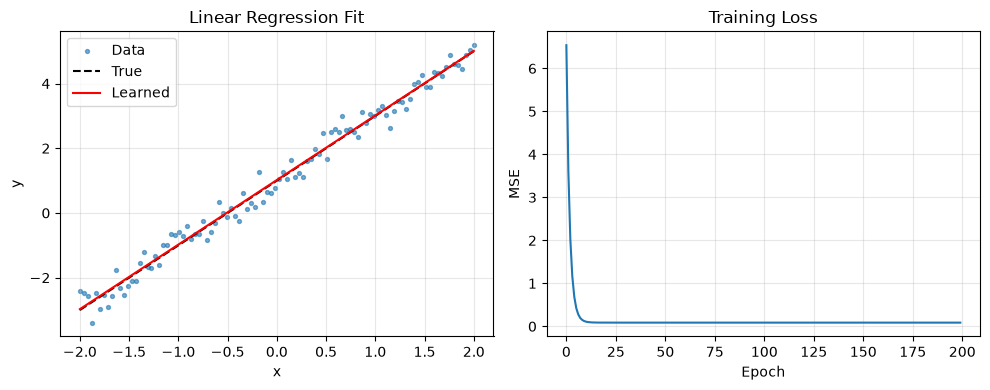

In [7]:
import torch
import matplotlib.pyplot as plt

# %matplotlib inline

# ----------------------------------------------------------------
# Linear regression: y = 2 * x + 1 + noise
# Minimise MSE loss with gradient descent (manual loop)
# ----------------------------------------------------------------
torch.manual_seed(42)

# Generate data
N = 100
x_data = torch.linspace(-2, 2, N)
y_true = 2.0 * x_data + 1.0
y_data = y_true + 0.3 * torch.randn(N)

# Parameters to learn
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

alpha = 0.1
n_epochs = 200
losses = []

for epoch in range(1, n_epochs + 1):
    # Forward: prediction
    y_pred = w * x_data + b

    # MSE loss
    loss = ((y_pred - y_data) ** 2).mean()

    # Backward
    loss.backward()

    # Gradient descent (manual, no optimiser)
    with torch.no_grad():
        w -= alpha * w.grad
        b -= alpha * b.grad

    # Zero gradients
    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

# Results
print(f"Learned w = {w.item():.4f}  (true = 2.0)")
print(f"Learned b = {b.item():.4f}  (true = 1.0)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(x_data.numpy(), y_data.numpy(), s=8, alpha=0.6, label="Data")
axes[0].plot(x_data.numpy(), y_true.numpy(), "k--", label="True")
axes[0].plot(x_data.numpy(), y_pred.detach().numpy(), "r-", label="Learned")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Linear Regression Fit")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Training Loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb02_linear_regression.png", dpi=150)
plt.show()

Final loss: 0.009241


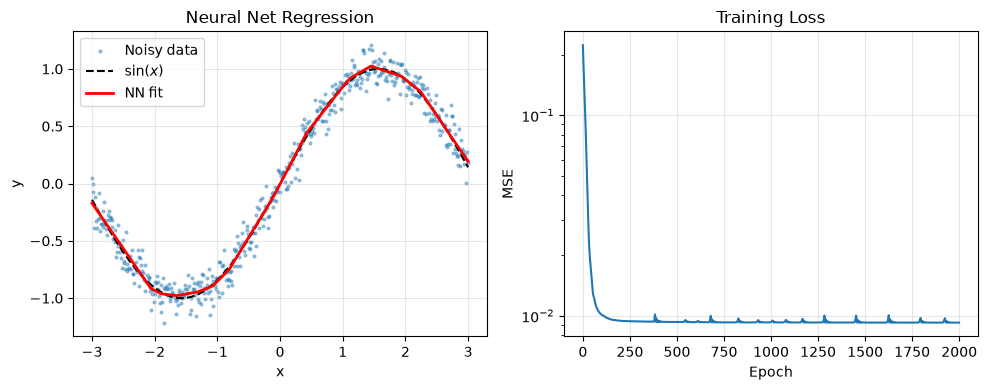

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# %matplotlib inline

# ----------------------------------------------------------------
# Simple neural net: learn a non-linear function
#   y = sin(x) + 0.1 * noise
# ----------------------------------------------------------------
torch.manual_seed(42)

# Data
N = 500
x_data = torch.linspace(-3, 3, N).unsqueeze(1)  # (N, 1)
y_data = torch.sin(x_data) + 0.1 * torch.randn(N, 1)

# Model: one hidden layer with 32 neurons, ReLU activation
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)
optimiser = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

n_epochs = 2000
losses = []

for epoch in range(1, n_epochs + 1):
    y_pred = model(x_data)
    loss = loss_fn(y_pred, y_data)

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    losses.append(loss.item())

# Evaluate
model.eval()
with torch.no_grad():
    y_pred_final = model(x_data)

print(f"Final loss: {losses[-1]:.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(x_data.numpy(), y_data.numpy(), s=4, alpha=0.4, label="Noisy data")
axes[0].plot(x_data.numpy(), torch.sin(x_data).numpy(), "k--", label=r"$\sin(x)$")
axes[0].plot(x_data.numpy(), y_pred_final.numpy(), "r-", lw=2, label="NN fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Neural Net Regression")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Training Loss")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb02_neural_net.png", dpi=150)
plt.show()

## Softmax and Log-Softmax

### Softmax

The softmax function converts logits $z_i$ into a probability distribution:

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}.
$$

Properties:
- Outputs are positive and sum to 1 (valid probabilities).
- It is **sensitive to scale**: large logits make the distribution peaky (more deterministic).

### Log-Softmax

The log-softmax is simply the log of the softmax:

$$
\log\text{softmax}(z_i) = z_i - \log\sum_{j} e^{z_j} = z_i - \text{LogSumExp}(z).
$$

### Why `log_softmax` is numerically stable

Computing $\log(\text{softmax}(z))$ naively involves two steps:

1.  $e^{z_i}$ — can **overflow** for large $z_i$ (e.g., $e^{1000}$ is beyond float range).
2.  $\log(\dots)$ — can produce $-\infty$ for very small probabilities (underflow).

`log_softmax` combines them into a single numerically stable operation:

$$
\log\text{softmax}(z_i) = z_i - \max_k z_k - \log\sum_{j} e^{z_j - \max_k z_k}.
$$

The subtraction of $\max_k z_k$ keeps all exponentials in a safe range.

### In RL

- Policies often output logits over discrete actions.
- We sample actions from $\pi(\cdot \mid s)$ — this is a **categorical** (multinomial) distribution.
- The policy-gradient loss uses $\log \pi_\theta(a \mid s)$, which is exactly `F.log_softmax`.

In [9]:
import torch
import torch.nn.functional as F
import numpy as np

# ----------------------------------------------------------------
# Compare naive log(softmax) vs log_softmax for large logits
# ----------------------------------------------------------------
logits = torch.tensor([1.0, 2.0, 100.0, -100.0])

# Naive approach: softmax then log
probs_naive = F.softmax(logits, dim=0)
log_naive = torch.log(probs_naive)

# Stable approach
log_stable = F.log_softmax(logits, dim=0)

print("Logits:            ", logits.numpy())
print("Softmax:           ", probs_naive.numpy())
print("log(softmax) naive:", log_naive.numpy())
print("log_softmax stable:", log_stable.numpy())
print("Are close?         ", torch.allclose(log_naive, log_stable, atol=1e-6))

# ----------------------------------------------------------------
# Demonstrate numeric issues with very large logits
# ----------------------------------------------------------------
big_logits = torch.tensor([0.0, 1e3, 2e3])

try:
    bad = torch.log(F.softmax(big_logits, dim=0))
    print("\nNaive log(softmax) with huge logits:", bad.numpy())
except RuntimeError as e:
    print(f"\nNaive approach failed: {e}")

# Stable version works fine
good = F.log_softmax(big_logits, dim=0)
print("log_softmax stable:", good.numpy())

Logits:             [   1.    2.  100. -100.]
Softmax:            [1.01e-43 2.75e-43 1.00e+00 0.00e+00]
log(softmax) naive: [-99.002266 -98.00082    0.             -inf]
log_softmax stable: [ -99.  -98.    0. -200.]
Are close?          False

Naive log(softmax) with huge logits: [-inf -inf   0.]
log_softmax stable: [-2000. -1000.     0.]


## Categorical Distribution in PyTorch

In RL, a discrete policy $\pi_\theta(\cdot \mid s)$ is a **categorical distribution** over actions.
PyTorch provides `torch.distributions.Categorical` which:

- Takes **logits** (preferred, more numerically stable) or **probs** as input.
- Supports `.sample()` to draw actions.
- Supports `.log_prob(actions)` to compute $\log \pi_\theta(a \mid s)$ — exactly what policy gradient needs.

**No need to manually compute softmax then sample** — `Categorical` handles it all in one place.

Action probs: [0.22125264 0.04041921 0.6646796  0.07364859]
Empirical probs: [0.22   0.0396 0.6655 0.0749]
Match?          True
Mean log-prob of sampled actions: -0.9261


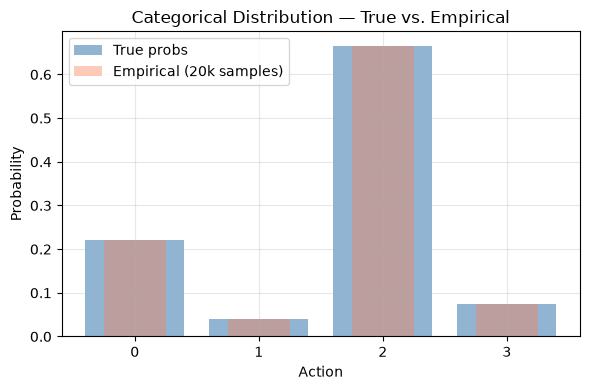

In [10]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

# %matplotlib inline

# ----------------------------------------------------------------
# Sampling from a categorical distribution in PyTorch
# ----------------------------------------------------------------
torch.manual_seed(42)

# Suppose we have logits for 4 actions
logits = torch.tensor([1.2, -0.5, 2.3, 0.1])
probs = torch.softmax(logits, dim=0)

print("Action probs:", probs.numpy())

# Create a categorical distribution (using logits — numerically stable)
action_dist = dist.Categorical(logits=logits)

# Sample many actions
n_samples = 20000
samples = action_dist.sample((n_samples,))
counts = torch.bincount(samples, minlength=4).float() / n_samples

print("Empirical probs:", counts.numpy())
print("Match?         ", torch.allclose(probs, counts, atol=1e-2))

# Log-probability of sampled actions — this is used in policy gradient
log_probs = action_dist.log_prob(samples)
print(f"Mean log-prob of sampled actions: {log_probs.mean().item():.4f}")

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
actions_idx = [0, 1, 2, 3]
ax.bar(actions_idx, probs.numpy(), alpha=0.6, label="True probs", color="steelblue")
ax.bar(actions_idx, counts.numpy(), alpha=0.4, label="Empirical (20k samples)",
       color="coral", width=0.5)
ax.set_xlabel("Action")
ax.set_ylabel("Probability")
ax.set_title("Categorical Distribution — True vs. Empirical")
ax.set_xticks(actions_idx)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/nb02_categorical.png", dpi=150)
plt.show()

## Summary

In this notebook we built the mathematical and software foundations for reinforcement learning:

| Concept | Why it matters in RL | Code tool |
|---|---|---|
| **Expectation** $\mathbb{E}[X]$ | Value functions $V^\pi(s), Q^\pi(s,a)$ are expectations | NumPy mean, conditional indexing |
| **Law of total probability** | Bellman equation: law of total expectation | Empirical verification |
| **Gradient ascent** | Policy gradient *maximises* $J(\theta)$ — opposite of supervised learning | Manual loops, PyTorch optim |
| **Log-derivative trick** | Core identity behind REINFORCE, A2C, PPO | `torch.log`, autograd check |
| **Autograd** | Automatic differentiation — never compute gradients by hand | `backward()`, `.grad` |
| **Softmax / log_softmax** | Convert policy logits to action probabilities; numerically stable | `F.log_softmax` |
| **Categorical distribution** | Sampling actions and computing log-probabilities | `dist.Categorical` |

With these tools, you are ready to implement RL algorithms in the coming notebooks.

## Exercises

Try these to consolidate your understanding. Solutions are in the `solutions/` directory.

### Exercise 1: Expectation of a transformed variable

Let $X \sim \text{Uniform}(0, 4)$. Compute $\mathbb{E}[X^2]$ analytically, then verify with a NumPy simulation ($N = 100000$).

### Exercise 2: Conditional expectation

Simulate a two-dice system. Let $X$ be the sum of two fair dice and $Y$ be the maximum of the two dice.
Compute $\mathbb{E}[X \mid Y = 6]$ empirically.

### Exercise 3: Gradient descent on a 2D function

Implement gradient descent to find the minimum of:

$$
f(x, y) = x^2 + 2y^2 + xy
$$

Start at $(x, y) = (3, 3)$ and use $\alpha = 0.05$. Plot the $(x, y)$ trajectory on a contour plot
of $f$.

### Exercise 4: Log-derivative trick with a Gaussian policy

Let $\pi_\theta(a \mid s) = \mathcal{N}(\mu = s \cdot \theta,\; \sigma = 1)$. Verify the log-derivative trick
numerically for this continuous distribution.

**Hints:**
- Use `torch.distributions.Normal`.
- $\log \pi(a \mid s) = -\frac{1}{2}\log(2\pi) - \frac{1}{2}\left(\frac{a - \mu}{\sigma}\right)^2$.

### Exercise 5: 2-layer network from scratch

Using only `torch.mm`, `torch.exp`, and manual gradient descent (no `nn.Module`, no `optim`), implement a
2-layer network:

$$
y = W_2 \cdot \text{ReLU}(W_1 x + b_1) + b_2
$$

and train it on the sine-wave data from the notebook.

## Further Reading

| Resource | Link / Note |
|---|---|
| PyTorch Autograd tutorial | https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html |
| Policy Gradient (REINFORCE) — Spinning Up | https://spinningup.openai.com/en/latest/algorithms/vpg.html |
| Probability Cheatsheet (Joe Blitzstein) | https://github.com/wzchen/probability_cheatsheet |
| The log-derivative trick (Lilian Weng) | https://lilianweng.github.io/posts/2018-04-08-policy-gradient/ |
| Pattern Recognition and Machine Learning (Bishop) | Chapter 1 — Probability theory foundations |
| Reinforcement Learning: An Introduction (Sutton & Barto) | Chapter 13 — Policy Gradient Methods |

> **Next notebook**: `03_gym_intro.ipynb` — learn the Gymnasium API and run your first environment.